In [1]:
import pandas as pd
import os
import glob
import gzip
import csv
import json
import sys
from tqdm import tqdm
import numpy as np
import itertools

import matplotlib.pyplot as plt
import seaborn as sns

from src import visualization as vis

## 1 Curating data

### 1.1 Collecting data unit sequences and metadata

In [104]:
# Defining sequence features
aa_alpha_features = ['fwr1_aa_alpha', 'cdr1_aa_alpha', 'fwr2_aa_alpha', 'cdr2_aa_alpha', 'fwr3_aa_alpha', 'cdr3_aa_alpha', 'fwr4_aa_alpha']
aa_beta_features = ['fwr1_aa_beta', 'cdr1_aa_beta', 'fwr2_aa_beta', 'cdr2_aa_beta', 'fwr3_aa_beta', 'cdr3_aa_beta', 'fwr4_aa_beta']
aa_features = aa_alpha_features + aa_beta_features

# Defining gene features
gene_alpha_features = ['v_call_alpha', 'j_call_alpha', 'cdr3_aa_alpha']
gene_beta_features = ['v_call_beta', 'd_call_beta', 'j_call_beta', 'cdr3_aa_beta']
gene_features = gene_alpha_features + gene_beta_features

In [105]:
# Collecting data unit sequences and metadata from data unit files

# Checking for precurated files
try: 
    sequences = pd.read_parquet('data/ots/curated/sequences.parquet')
    dataunit_metadata = pd.read_csv('data/ots/curated/dataunit_metadata.csv')
except FileNotFoundError:

    # Looping over data unit files
    dataunit_headers = []
    dataunits = []
    for file_path in tqdm(glob.glob('data/ots/raw/*.csv.gz')):
        
        # Extracting data unit metadata header:
        with gzip.open(file_path, 'rt', newline='', encoding='utf-8') as f:
            first_line = f.readline()
            reader = csv.reader([first_line])
            for row in reader:

                # Parsing as json
                json_str = row[0]
                dataunit_header = pd.Series(json.loads(json_str))
                break

        # Skipping gamma-delta T-cell types
        if dataunit_header['TType'] == 'gamma-delta':
            continue

        # Extracting data unit sequences
        dataunit = pd.read_csv(file_path, skiprows=1, usecols=gene_features+aa_features)
    
        # Filtering away sequences that lack information
        dataunit.dropna(inplace=True)

        # Noting how many sequences in data unit are paired 
        dataunit_header['SequencesPaired'] = len(dataunit)
        dataunit_header['SequencesPairedUnique'] = len(dataunit.drop_duplicates())
        
        # Adding annotations
        dataunit_header['Path'] = file_path
        dataunit['Run'] = dataunit_header['Run']

        dataunits.append(dataunit)
        dataunit_headers.append(dataunit_header)


    # Assembling data and dataunit_metadata
    sequences = pd.concat(dataunits)
    dataunit_metadata = pd.concat(dataunit_headers, axis=1).T
    
    # Defining repertoires
    dataunit_metadata['SubjectProxy'] = np.where(
        dataunit_metadata['Subject'] == 'no',
        dataunit_metadata['Run'],
        dataunit_metadata['Subject']
    )
    dataunit_metadata['RepertoireId'] = dataunit_metadata['SubjectProxy'].astype('category').cat.codes
    sequences = sequences.merge(dataunit_metadata[['Run', 'RepertoireId']], on='Run', how='left')

    sequences.to_parquet('data/ots/curated/sequences.parquet')
    dataunit_metadata.to_csv('data/ots/curated/dataunit_metadata.csv', index=False)

### 1.2 Characterising data

In [106]:
# Descriptive statistics
print(f"Filtered to {len(dataunit_metadata):,} data units aggregated to {dataunit_metadata.RepertoireId.nunique():,} repertoires from {dataunit_metadata.Author.nunique():,} studies")
print(f"{dataunit_metadata.SequencesPaired.sum():,} paired sequences available")

Filtered to 2,129 data units aggregated to 1,733 repertoires from 62 studies
5,083,688 paired sequences available


#### 1.2.1 Characterisation of repertoire sizes

In [107]:
# Manual binning
bins = (1, 1000, 5000, 10000, 50000, 1000000)
labels = ['1-1,000', '1,001-5,000', '5,001-10,000', '10,001-50,000', '50,001+']
pd.cut(
    dataunit_metadata.groupby('RepertoireId').SequencesPaired.sum(),
    bins, labels=labels
).value_counts().sort_index()

SequencesPaired
1-1,000           447
1,001-5,000      1164
5,001-10,000       75
10,001-50,000      40
50,001+             5
Name: count, dtype: int64

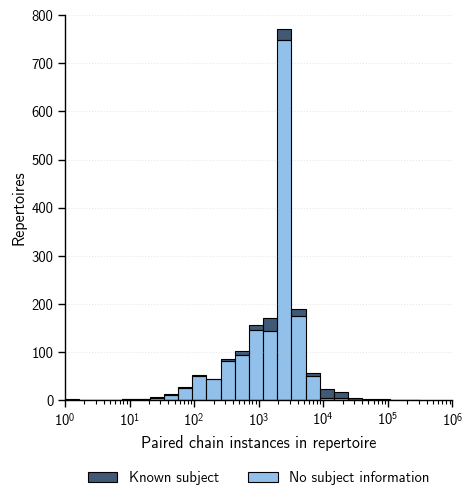

In [108]:
plt.figure(figsize=(5, 5))
sns.set_context("paper", font_scale=1.2)

ax = sns.histplot(
    data=dataunit_metadata.groupby('RepertoireId').agg({
        'SequencesPaired': 'sum',
        'Subject': lambda s: 'No subject information' if max(s) == 'no' else 'Known subject',
    }),
    x='SequencesPaired',
    hue='Subject',
    multiple='stack',
    log_scale=True,
    palette=[vis.blue, vis.light_blue],
    bins=25,
)

sns.despine(top=True, right=True)
if ax.get_legend():
    old_legend = ax.get_legend()
    handles = old_legend.legend_handles
    labels = [t.get_text() for t in old_legend.get_texts()]
    old_legend.remove()
ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    title=None
)
plt.grid(axis='y', linestyle='dotted', alpha=0.3)
plt.xlim(1,1e6)
plt.ylim(0,800)

plt.title("")
plt.xlabel("Paired chain instances in repertoire")
plt.ylabel("Repertoires")

plt.savefig("figures/repertoire_pairedseqs.png", dpi=600, bbox_inches='tight', transparent=True)

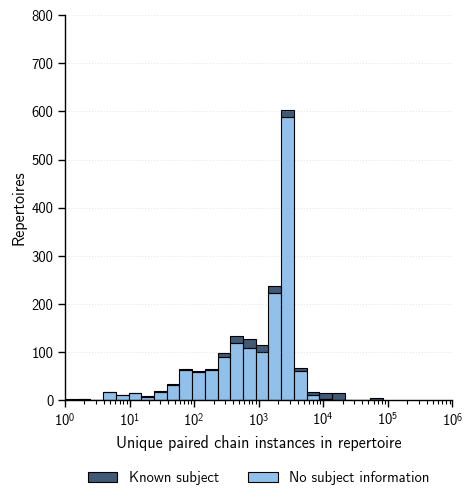

In [109]:
plt.figure(figsize=(5, 5))
sns.set_context("paper", font_scale=1.2)

ax = sns.histplot(
    data=dataunit_metadata.groupby('RepertoireId').agg({
        'SequencesPairedUnique': 'sum',
        'Subject': lambda s: 'No subject information' if max(s) == 'no' else 'Known subject',
    }),
    x='SequencesPairedUnique',
    hue='Subject',
    multiple='stack',
    palette=[vis.blue, vis.light_blue],
    log_scale=True,
    bins=25,
)

sns.despine(top=True, right=True)
if ax.get_legend():
    old_legend = ax.get_legend()
    handles = old_legend.legend_handles
    labels = [t.get_text() for t in old_legend.get_texts()]
    old_legend.remove()
ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    title=None,
)
plt.grid(axis='y', linestyle='dotted', alpha=0.3)
plt.xlim(1,1e6)
plt.ylim(0,800)

plt.xlim(1)
plt.title("")
plt.xlabel("Unique paired chain instances in repertoire")
plt.ylabel("Repertoires")

plt.savefig("figures/repertoire_uniquepairedseqs.png", dpi=600, bbox_inches='tight', transparent=True)

#### 1.2.2 Characterisation of repertoire categories

In [110]:
repertoire_sizes = dataunit_metadata.groupby('RepertoireId').agg({ 
    'Disease': 'max', 
    'TType': 'max', 
    'SequencesPaired': 'sum' 
}) 
disease_sizes = repertoire_sizes.reset_index().groupby('Disease').agg({ 
    'RepertoireId': 'count', 
    'SequencesPaired': 'sum' 
}).sort_values('SequencesPaired')
ttype_sizes = repertoire_sizes.reset_index().groupby('TType').agg({ 
    'RepertoireId': 'count', 
    'SequencesPaired': 'sum' 
}).sort_values('SequencesPaired')

/var/folders/ls/l5m3kcsd4lddcv2284nfc4b40000gn/T/ipykernel_1146/938470143.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([0] + [l._text + "·10$^6$" for l in ax2.get_xticklabels()][1:])


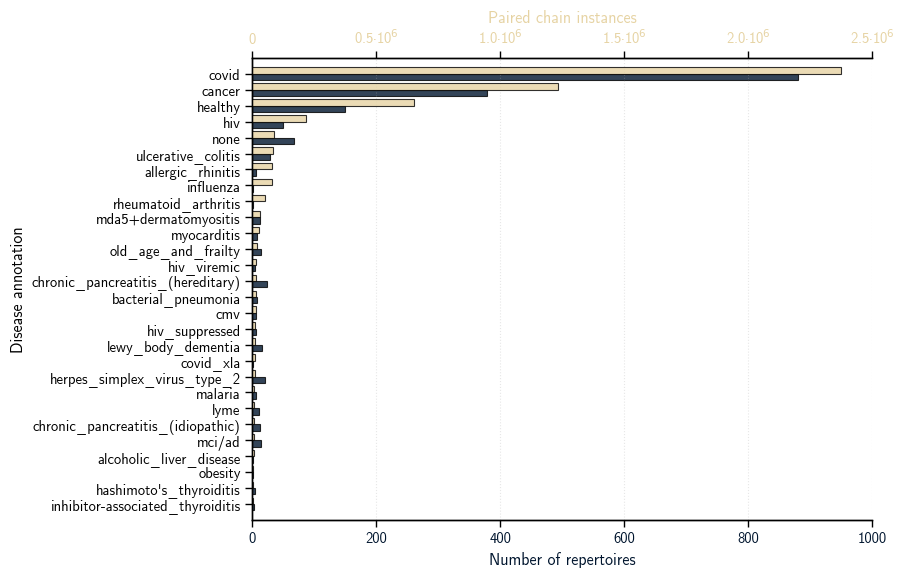

In [111]:
y_pos = np.arange(len(disease_sizes))
height = 0.4

fig, ax1 = plt.subplots(figsize=(8, 6))

rects1 = ax1.barh(y_pos - height/2, disease_sizes.RepertoireId, 
                  height, label='Repertoires', color=vis.dark_blue, alpha=0.8, edgecolor='k')
ax1.set_xlabel('Number of repertoires', color=vis.dark_blue)
ax1.tick_params(axis='x', labelcolor=vis.dark_blue)
ax1.set_xlim(0,1000)
ax1.set_ylim(-1,len(disease_sizes))
ax1.set_yticks(y_pos)
ax1.set_yticklabels(disease_sizes.index)
ax1.set_ylabel('Disease annotation')
ax1.grid(axis='x', linestyle='dotted', alpha=0.3)
ax1.spines.right.set_visible(False)

ax2 = ax1.twiny() 
rects2 = ax2.barh(y_pos + height/2, disease_sizes['SequencesPaired'], 
                  height, label='Sequences', color=vis.light_gold, alpha=0.8, edgecolor='k')
ax2.set_xlabel('Paired chain instances', color=vis.light_gold)
ax2.tick_params(axis='x', labelcolor=vis.light_gold)
ax2.set_xlim(0,2.5e6)
ax2.set_xticklabels([0] + [l._text + "·10$^6$" for l in ax2.get_xticklabels()][1:])
ax2.spines.right.set_visible(False)

plt.savefig("figures/repertoire_diseases.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

/var/folders/ls/l5m3kcsd4lddcv2284nfc4b40000gn/T/ipykernel_1146/2913274414.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([0] + [l._text + "·10$^6$" for l in ax2.get_xticklabels()][1:])


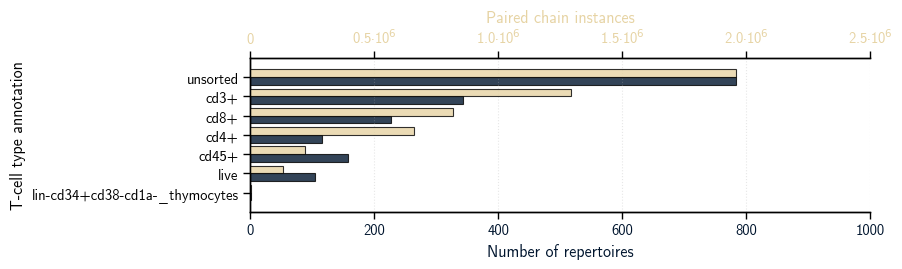

In [112]:
# Preparation of coordinates
y_pos = np.arange(len(ttype_sizes))
height = 0.4

fig, ax1 = plt.subplots(figsize=(8, 2))

rects1 = ax1.barh(y_pos - height/2, ttype_sizes.RepertoireId, 
                  height, label='Repertoires', color=vis.dark_blue, alpha=0.8, edgecolor='k')
ax1.set_xlabel('Number of repertoires', color=vis.dark_blue)
ax1.tick_params(axis='x', labelcolor=vis.dark_blue)
ax1.set_xlim(0,1000)
ax1.set_ylim(-1,len(ttype_sizes))
ax1.set_yticks(y_pos)
ax1.set_yticklabels(ttype_sizes.index)
ax1.set_ylabel('T-cell type annotation')
ax1.grid(axis='x', linestyle='dotted', alpha=0.3)
ax1.spines.right.set_visible(False)

ax2 = ax1.twiny() 
rects2 = ax2.barh(y_pos + height/2, ttype_sizes['SequencesPaired'], 
                  height, label='Sequences', color=vis.light_gold, alpha=0.8, edgecolor='k')
ax2.set_xlabel('Paired chain instances', color=vis.light_gold)
ax2.tick_params(axis='x', labelcolor=vis.light_gold)
ax2.set_xlim(0,2.5e6)
ax2.set_xticklabels([0] + [l._text + "·10$^6$" for l in ax2.get_xticklabels()][1:])
ax2.spines.right.set_visible(False)

plt.savefig("figures/repertoire_ttypes.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### 1.3 Curating pairings

In [113]:
from Levenshtein import distance as levdist

def pair_agg_measures(seq_repertoire_ids):

    intra_repertoire_ids, intra_instances = np.unique_counts(seq_repertoire_ids)
    pan_instances = intra_instances.sum()
    pan_repertoires = len(intra_repertoire_ids)

    return pd.Series({
        'PanInstances': pan_instances,
        'PanRepertoires': pan_repertoires,
        'PanInstancesMean': pan_instances / pan_repertoires,
        'IntraInstances': intra_instances,
        'RepertoireIds': intra_repertoire_ids,
    })
    

def distance_matrix(aa_seqs, dist_func):
    n = len(aa_seqs) 
    distances = np.zeros((n,n))
    for i, j in itertools.combinations(range(n), 2):
        distances[i,j] = dist_func(aa_seqs[i], aa_seqs[j])
        distances[j,i] = distances[i,j]
    return distances


def chain_agg_measures(pair_instances, pair_repertoire_ids, cdr3_aa_seqs):
    # Precalculating tensors
    pair_instances = np.array(pair_instances)
    p_a_b = pair_instances / pair_instances.sum()
    p_aa_b = np.outer(p_a_b, p_a_b)

    # Propogating instance measures
    chain_instances = pair_instances.sum()
    chain_repertoire_ids, intra_unique_pairings = np.unique_counts(list(itertools.chain(*pair_repertoire_ids)))
    pan_repertoires = len(chain_repertoire_ids)

    # Unique pairings
    pan_unique_pairings = pair_instances.shape[0]

    # Perplexity
    entropy = - np.sum(p_a_b * np.log2(p_a_b))
    perplexity = 2**entropy
    
    # Simpson index
    simpson = np.sum(p_a_b**2)

    # Expected Levenshtein
    d_aa = distance_matrix(cdr3_aa_seqs, levdist)
    exp_dist_lev = (p_aa_b * d_aa).sum()

    return pd.Series({
        'PanInstances': chain_instances,
        'PanRepertoires': pan_repertoires,
        'PanInstancesMean': chain_instances / pan_repertoires,
        'CDR3s': list(cdr3_aa_seqs),
        'RepertoireIds': chain_repertoire_ids,
        'PanUniquePairings': pan_unique_pairings,
        'IntraUniquePairings': intra_unique_pairings,
        'Perplexity': perplexity,
        'SimpsonIndex': simpson,
        'ExpectedCDR3Levenshtein': exp_dist_lev,
    })


#### 1.3.1 Pan-repertoire

In [114]:
# Pan-repertoire pair curation
# Checking for precurated file
try: 
    gene_pairs = pd.read_parquet('data/ots/curated/gene_pairs.parquet')
    aa_pairs = pd.read_parquet('data/ots/curated/aa_pairs.parquet')
    
except FileNotFoundError:

    # Aggregating unique pairs by either definition 
    gene_pairs = sequences.groupby(gene_features).apply(lambda subset: pair_agg_measures(subset.RepertoireId))
    aa_pairs = sequences.groupby(aa_features).apply(lambda subset: pair_agg_measures(subset.RepertoireId))

    gene_pairs.to_parquet('data/ots/curated/gene_pairs.parquet')
    aa_pairs.to_parquet('data/ots/curated/aa_pairs.parquet')


print(f"{len(gene_pairs):,} unique pairs when grouping by V-gene, J-gene, and CDR3")
print(f"{len(aa_pairs):,} unique pairs when grouping by sequence identity")

1,544,941 unique pairs when grouping by V-gene, J-gene, and CDR3
1,552,458 unique pairs when grouping by sequence identity


In [115]:
# Pan-repertoire chain curation
# Checking for precurated file
try: 
    gene_alphas = pd.read_parquet('data/ots/curated/gene_alphas.parquet')
    aa_alphas = pd.read_parquet('data/ots/curated/aa_alphas.parquet')
    gene_betas = pd.read_parquet('data/ots/curated/gene_betas.parquet')
    aa_betas = pd.read_parquet('data/ots/curated/aa_betas.parquet')

except FileNotFoundError:

    # Aggregating unique chains by either definition 
    gene_alphas = (
        gene_pairs
        .groupby(gene_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_beta')
    )))
    aa_alphas = (
        aa_pairs
        .groupby(aa_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_beta')
    )))

    gene_betas = (
        gene_pairs
        .groupby(gene_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_alpha')
    )))
    aa_betas = (
        aa_pairs
        .groupby(aa_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_alpha')
    )))

    gene_alphas.to_parquet('data/ots/curated/gene_alphas.parquet')
    aa_alphas.to_parquet('data/ots/curated/aa_alphas.parquet')
    gene_betas.to_parquet('data/ots/curated/gene_betas.parquet')
    aa_betas.to_parquet('data/ots/curated/aa_betas.parquet')


print(f"{len(gene_alphas):,} unique alpha chains when grouping by V-gene, J-gene, and CDR3")
print(f"{len(gene_betas):,} unique beta chains when grouping by V-gene, J-gene, and CDR3")
print(f"{len(aa_alphas):,} unique alpha chains when grouping by sequence identity")
print(f"{len(aa_betas):,} unique beta chains when grouping by sequence identity")

1,020,192 unique alpha chains when grouping by V-gene, J-gene, and CDR3
1,473,969 unique beta chains when grouping by V-gene, J-gene, and CDR3
1,026,738 unique alpha chains when grouping by sequence identity
1,464,973 unique beta chains when grouping by sequence identity


##### 1.3.1.1 Healthy subset

In [116]:
# Curating healthy pairs
try: 
    gene_pairs_healthy = pd.read_parquet('data/ots/curated/gene_pairs_healthy.parquet')
    aa_pairs_healthy = pd.read_parquet('data/ots/curated/aa_pairs_healthy.parquet')
    gene_alphas_healthy = pd.read_parquet('data/ots/curated/gene_alphas_healthy.parquet')
    aa_alphas_healthy = pd.read_parquet('data/ots/curated/aa_alphas_healthy.parquet')
    gene_betas_healthy = pd.read_parquet('data/ots/curated/gene_betas_healthy.parquet')
    aa_betas_healthy = pd.read_parquet('data/ots/curated/aa_betas_healthy.parquet')

except FileNotFoundError:

    # Filtering for healthy sequences
    sequences_healthy = sequences[sequences.Run.isin(dataunit_metadata[dataunit_metadata.Disease == 'healthy'].Run)]

    # Aggregating unique pairs by either definition 
    gene_pairs_healthy = sequences_healthy.groupby(gene_features).apply(lambda subset: pair_agg_measures(subset.RepertoireId))
    aa_pairs_healthy = sequences_healthy.groupby(aa_features).apply(lambda subset: pair_agg_measures(subset.RepertoireId))

    gene_pairs_healthy.to_parquet('data/ots/curated/gene_pairs_healthy.parquet')
    aa_pairs_healthy.to_parquet('data/ots/curated/aa_pairs_healthy.parquet')

    # Aggregating unique chains by either definition 
    gene_alphas_healthy = (
        gene_pairs_healthy
        .groupby(gene_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_beta')
    )))
    aa_alphas_healthy = (
        aa_pairs_healthy
        .groupby(aa_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_beta')
    )))

    gene_betas_healthy = (
        gene_pairs_healthy
        .groupby(gene_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_alpha')
    )))
    aa_betas_healthy = (
        aa_pairs_healthy
        .groupby(aa_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_alpha')
    )))

    gene_alphas_healthy.to_parquet('data/ots/curated/gene_alphas_healthy.parquet')
    aa_alphas_healthy.to_parquet('data/ots/curated/aa_alphas_healthy.parquet')
    gene_betas_healthy.to_parquet('data/ots/curated/gene_betas_healthy.parquet')
    aa_betas_healthy.to_parquet('data/ots/curated/aa_betas_healthy.parquet')

print(f"{len(gene_pairs_healthy):,} unique pairs from healthy repertoires when grouping by V-gene, J-gene, and CDR3")
print(f"{len(aa_pairs_healthy):,} unique pairs from healthy repertoires when grouping by sequence identity")
print(f"{len(gene_alphas_healthy):,} unique alpha chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3")
print(f"{len(gene_betas_healthy):,} unique beta chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3")
print(f"{len(aa_alphas_healthy):,} unique alpha chains from healthy repertoires when grouping by sequence identity")
print(f"{len(aa_betas_healthy):,} unique beta chains from healthy repertoires when grouping by sequence identity")

163,464 unique pairs from healthy repertoires when grouping by V-gene, J-gene, and CDR3
164,714 unique pairs from healthy repertoires when grouping by sequence identity
135,747 unique alpha chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3
157,761 unique beta chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3
136,629 unique alpha chains from healthy repertoires when grouping by sequence identity
157,949 unique beta chains from healthy repertoires when grouping by sequence identity


In [ ]:
# Rerunning analyses with healthy only
if False: # Switch to rerun with healthy only
    gene_pairs = gene_pairs_healthy
    aa_pairs = aa_pairs_healthy
    gene_alphas = gene_alphas_healthy
    aa_alphas = aa_alphas_healthy
    gene_betas = gene_betas_healthy
    aa_betas = aa_betas_healthy

##### 1.3.1.2 Covid subset

In [118]:
# Curating covid pairs
try: 
    gene_pairs_covid = pd.read_parquet('data/ots/curated/gene_pairs_covid.parquet')
    aa_pairs_covid = pd.read_parquet('data/ots/curated/aa_pairs_covid.parquet')
    gene_alphas_covid = pd.read_parquet('data/ots/curated/gene_alphas_covid.parquet')
    aa_alphas_covid = pd.read_parquet('data/ots/curated/aa_alphas_covid.parquet')
    gene_betas_covid = pd.read_parquet('data/ots/curated/gene_betas_covid.parquet')
    aa_betas_covid = pd.read_parquet('data/ots/curated/aa_betas_covid.parquet')

except FileNotFoundError:

    # Filtering for covid sequences
    sequences_covid = sequences[sequences.Run.isin(dataunit_metadata[dataunit_metadata.Disease == 'covid'].Run)]

    # Aggregating unique pairs by either definition 
    gene_pairs_covid = sequences_covid.groupby(gene_features).apply(lambda subset: pair_agg_measures(subset.RepertoireId))
    aa_pairs_covid = sequences_covid.groupby(aa_features).apply(lambda subset: pair_agg_measures(subset.RepertoireId))

    gene_pairs_covid.to_parquet('data/ots/curated/gene_pairs_covid.parquet')
    aa_pairs_covid.to_parquet('data/ots/curated/aa_pairs_covid.parquet')

    # Aggregating unique chains by either definition 
    gene_alphas_covid = (
        gene_pairs_covid
        .groupby(gene_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_beta')
    )))
    aa_alphas_covid = (
        aa_pairs_covid
        .groupby(aa_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_beta')
    )))

    gene_betas_covid = (
        gene_pairs_covid
        .groupby(gene_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_alpha')
    )))
    aa_betas_covid = (
        aa_pairs_covid
        .groupby(aa_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            subset.RepertoireIds,
            subset.index.get_level_values('cdr3_aa_alpha')
    )))

    gene_alphas_covid.to_parquet('data/ots/curated/gene_alphas_covid.parquet')
    aa_alphas_covid.to_parquet('data/ots/curated/aa_alphas_covid.parquet')
    gene_betas_covid.to_parquet('data/ots/curated/gene_betas_covid.parquet')
    aa_betas_covid.to_parquet('data/ots/curated/aa_betas_covid.parquet')

print(f"{len(gene_pairs_covid):,} unique pairs from covid repertoires when grouping by V-gene, J-gene, and CDR3")
print(f"{len(aa_pairs_covid):,} unique pairs from covid repertoires when grouping by sequence identity")
print(f"{len(gene_alphas_covid):,} unique alpha chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3")
print(f"{len(gene_betas_covid):,} unique beta chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3")
print(f"{len(aa_alphas_covid):,} unique alpha chains from healthy repertoires when grouping by sequence identity")
print(f"{len(aa_betas_covid):,} unique beta chains from healthy repertoires when grouping by sequence identity")

576,959 unique pairs from covid repertoires when grouping by V-gene, J-gene, and CDR3
582,124 unique pairs from covid repertoires when grouping by sequence identity
441,679 unique alpha chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3
552,172 unique beta chains from healthy repertoires when grouping by V-gene, J-gene, and CDR3
445,755 unique alpha chains from healthy repertoires when grouping by sequence identity
550,925 unique beta chains from healthy repertoires when grouping by sequence identity


### 1.3.2 Intra-repertoire

In [133]:
# Intra-repertoire pair curation
# Checking for precurated file
try: 
    gene_pairs_intra = pd.read_parquet('data/ots/curated/gene_pairs_intra.parquet')
    aa_pairs_intra = pd.read_parquet('data/ots/curated/aa_pairs_intra.parquet')
    
except FileNotFoundError:

    # Aggregating unique pairs by either definition 
    gene_pairs_intra = sequences.groupby(['RepertoireId'] + gene_features).apply(lambda subset: pair_agg_measures([-1]*len(subset)))
    aa_pairs_intra = sequences.groupby(['RepertoireId'] + aa_features).apply(lambda subset: pair_agg_measures([-1]*len(subset)))

    gene_pairs_intra.to_parquet('data/ots/curated/gene_pairs_intra.parquet')
    aa_pairs_intra.to_parquet('data/ots/curated/aa_pairs_intra.parquet')

In [134]:
# Intra-repertoire chain curation
# Checking for precurated file
try: 
    gene_alphas_intra = pd.read_parquet('data/ots/curated/gene_alphas_intra.parquet')
    aa_alphas_intra = pd.read_parquet('data/ots/curated/aa_alphas_intra.parquet')
    gene_betas_intra = pd.read_parquet('data/ots/curated/gene_betas_intra.parquet')
    aa_betas_intra = pd.read_parquet('data/ots/curated/aa_betas_intra.parquet')

except FileNotFoundError:

    # Aggregating unique chains by either definition 
    gene_alphas_intra = (
        gene_pairs_intra
        .groupby(['RepertoireId'] + gene_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            [[-1]]*len(subset),
            subset.index.get_level_values('cdr3_aa_beta')
    )))
    aa_alphas_intra = (
        aa_pairs_intra
        .groupby(['RepertoireId'] + aa_alpha_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            [[-1]]*len(subset),
            subset.index.get_level_values('cdr3_aa_beta')
    )))

    gene_betas_intra = (
        gene_pairs_intra
        .groupby(['RepertoireId'] + gene_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            [[-1]]*len(subset),
            subset.index.get_level_values('cdr3_aa_alpha')
    )))
    aa_betas_intra = (
        aa_pairs_intra
        .groupby(['RepertoireId'] + aa_beta_features)
        .apply(lambda subset: chain_agg_measures(
            subset.PanInstances,
            [[-1]]*len(subset),
            subset.index.get_level_values('cdr3_aa_alpha')
    )))

    gene_alphas_intra.to_parquet('data/ots/curated/gene_alphas_intra.parquet')
    aa_alphas_intra.to_parquet('data/ots/curated/aa_alphas_intra.parquet')
    gene_betas_intra.to_parquet('data/ots/curated/gene_betas_intra.parquet')
    aa_betas_intra.to_parquet('data/ots/curated/aa_betas_intra.parquet')

### 1.4 Characterising pairings

/var/folders/ls/l5m3kcsd4lddcv2284nfc4b40000gn/T/ipykernel_1146/2449434050.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(['0'] + [f"{float(l._text):.1f}" + r"·10$^{6}$" for l in axes[0].get_yticklabels()[1:]])
/var/folders/ls/l5m3kcsd4lddcv2284nfc4b40000gn/T/ipykernel_1146/2449434050.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(['0'] + [f"{float(l._text):.1f}" + r"·10$^{6}$" for l in axes[1].get_yticklabels()[1:]])


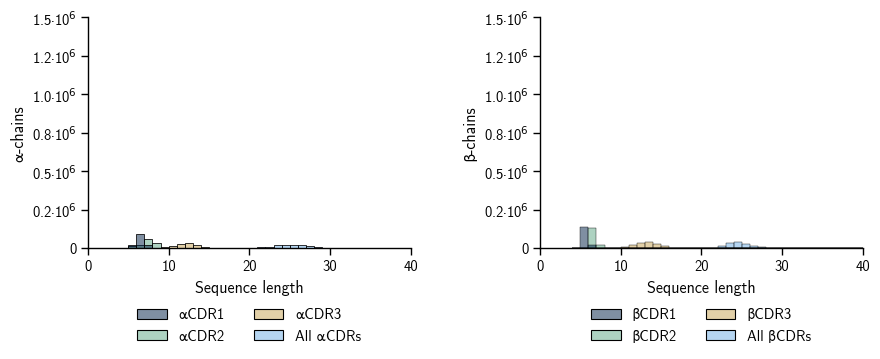

In [276]:
aa_alphas_cdrlen = aa_alphas.reset_index()[['cdr1_aa_alpha', 'cdr2_aa_alpha', 'cdr3_aa_alpha']].map(len)
aa_alphas_cdrlen['cdrs_aa_alpha'] = aa_alphas_cdrlen.sum(axis=1)
aa_betas_cdrlen = aa_betas.reset_index()[['cdr1_aa_beta', 'cdr2_aa_beta', 'cdr3_aa_beta']].map(len)
aa_betas_cdrlen['cdrs_aa_beta'] = aa_betas_cdrlen.sum(axis=1)

fig, axes = plt.subplots(1,2, figsize=(10,3))
fig.subplots_adjust(wspace=0.4)

sns.histplot(aa_alphas_cdrlen, binwidth=1, ax=axes[0])
sns.despine(top=True, right=True)
axes[0].set_xlim(0,40)
axes[0].set_ylim(0,1.5e6)
axes[0].set_yticklabels(['0'] + [f"{float(l._text):.1f}" + r"·10$^{6}$" for l in axes[0].get_yticklabels()[1:]])
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("α-chains")
if axes[0].get_legend():
    old_legend = axes[0].get_legend()
    handles = old_legend.legend_handles
    labels = ["αCDR1", "αCDR2", "αCDR3", "All αCDRs"]
    old_legend.remove()
axes[0].legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False,
    title=None
)

sns.histplot(aa_betas_cdrlen, binwidth=1, ax=axes[1])
axes[1].set_xlim(0,40)
axes[1].set_ylim(0,1.5e6)
axes[1].set_yticklabels(['0'] + [f"{float(l._text):.1f}" + r"·10$^{6}$" for l in axes[1].get_yticklabels()[1:]])
axes[1].set_xlabel("Sequence length")
axes[1].set_ylabel("β-chains")
if axes[1].get_legend():
    old_legend = axes[1].get_legend()
    handles = old_legend.legend_handles
    labels = ["βCDR1", "βCDR2", "βCDR3", "All βCDRs"]
    old_legend.remove()
axes[1].legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False,
    title=None
)

plt.savefig("figures/cdr_lengths.png", dpi=600, bbox_inches='tight', transparent=True)

## 2 Instances

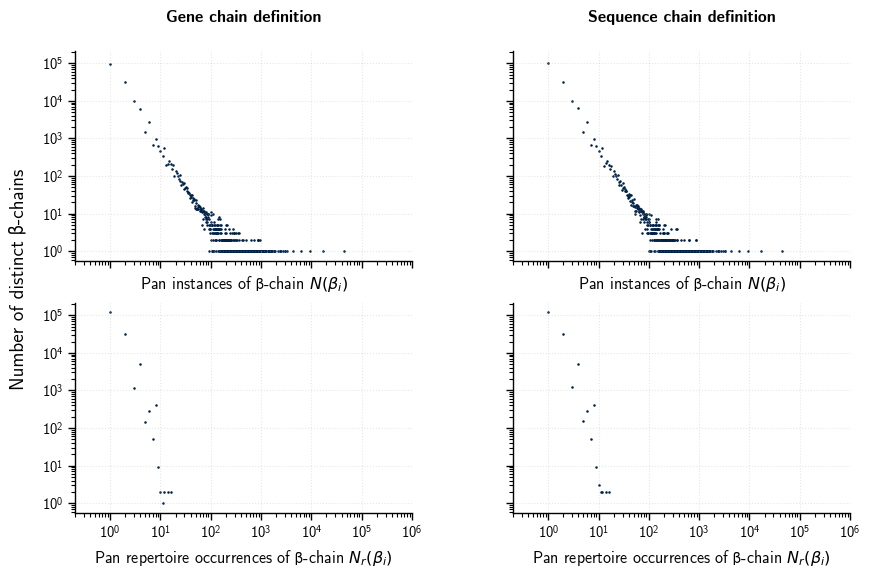

In [277]:
# Beta chain instances
gene_betas_paninstances = gene_betas.PanInstances.value_counts().sort_index()
gene_betas_panrepertoires = gene_betas.PanRepertoires.value_counts().sort_index()
aa_betas_paninstances = aa_betas.PanInstances.value_counts().sort_index()
aa_betas_panrepertoires = aa_betas.PanRepertoires.value_counts().sort_index()

fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.3, hspace=0.2)

axes[0,0].set_xlim(0.2,1e6)
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

axes[0,0].scatter(gene_betas_paninstances.index, gene_betas_paninstances, s=1)
axes[0,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")
axes[0,0].set_title('Gene chain definition', y=1.1)
axes[0,0].grid(linestyle='dotted', alpha=0.3)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)

axes[0,1].scatter(aa_betas_paninstances.index, aa_betas_paninstances, s=1)
axes[0,1].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")
axes[0,1].set_title('Sequence chain definition', y=1.1)
axes[0,1].grid(linestyle='dotted', alpha=0.3)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)

axes[1,0].scatter(gene_betas_panrepertoires.index, gene_betas_panrepertoires, s=1)
axes[1,0].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")
axes[1,0].grid(linestyle='dotted', alpha=0.3)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)

axes[1,1].scatter(aa_betas_panrepertoires.index, aa_betas_panrepertoires, s=1)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")
axes[1,1].grid(linestyle='dotted', alpha=0.3)
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)

fig.supylabel("Number of distinct β-chains", x=0.06)

plt.savefig("figures/instances_beta.png", dpi=600, bbox_inches='tight', transparent=True)

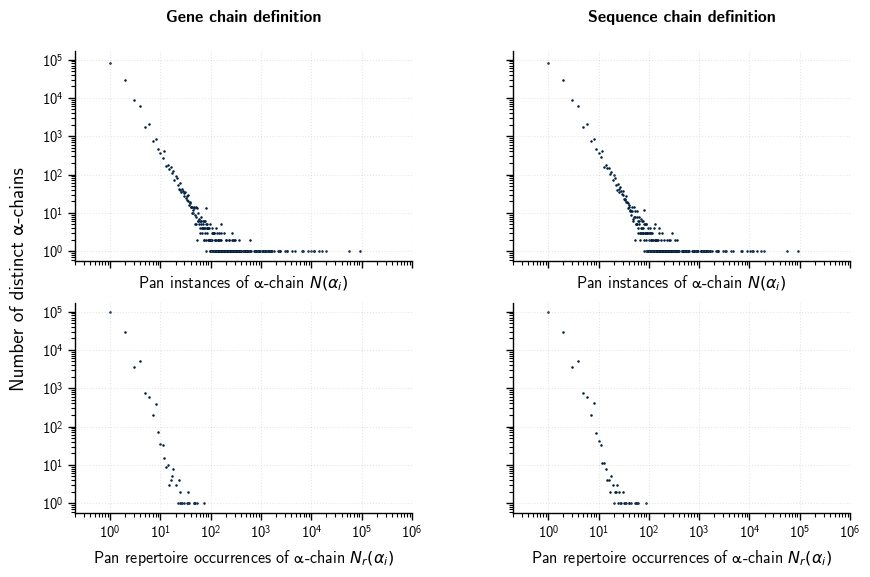

In [278]:
# Alpha chain instances
gene_alphas_paninstances = gene_alphas.PanInstances.value_counts().sort_index()
gene_alphas_panrepertoires = gene_alphas.PanRepertoires.value_counts().sort_index()
aa_alphas_paninstances = aa_alphas.PanInstances.value_counts().sort_index()
aa_alphas_panrepertoires = aa_alphas.PanRepertoires.value_counts().sort_index()

fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.3, hspace=0.2)

axes[0,0].set_xlim(0.2,1e6)
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

axes[0,0].scatter(gene_alphas_paninstances.index, gene_alphas_paninstances, s=1)
axes[0,0].set_xlabel(r"Pan instances of α-chain $N(\alpha_i)$")
axes[0,0].set_title('Gene chain definition', y=1.1)
axes[0,0].grid(linestyle='dotted', alpha=0.3)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)

axes[0,1].scatter(aa_alphas_paninstances.index, aa_alphas_paninstances, s=1)
axes[0,1].set_xlabel(r"Pan instances of α-chain $N(\alpha_i)$")
axes[0,1].set_title('Sequence chain definition', y=1.1)
axes[0,1].grid(linestyle='dotted', alpha=0.3)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)

axes[1,0].scatter(gene_alphas_panrepertoires.index, gene_alphas_panrepertoires, s=1)
axes[1,0].set_xlabel(r"Pan repertoire occurrences of α-chain $N_r(\alpha_i)$")
axes[1,0].grid(linestyle='dotted', alpha=0.3)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)

axes[1,1].scatter(aa_alphas_panrepertoires.index, aa_alphas_panrepertoires, s=1)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of α-chain $N_r(\alpha_i)$")
axes[1,1].grid(linestyle='dotted', alpha=0.3)
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)

fig.supylabel("Number of distinct α-chains", x=0.06)

plt.savefig("figures/instances_alpha.png", dpi=600, bbox_inches='tight', transparent=True)

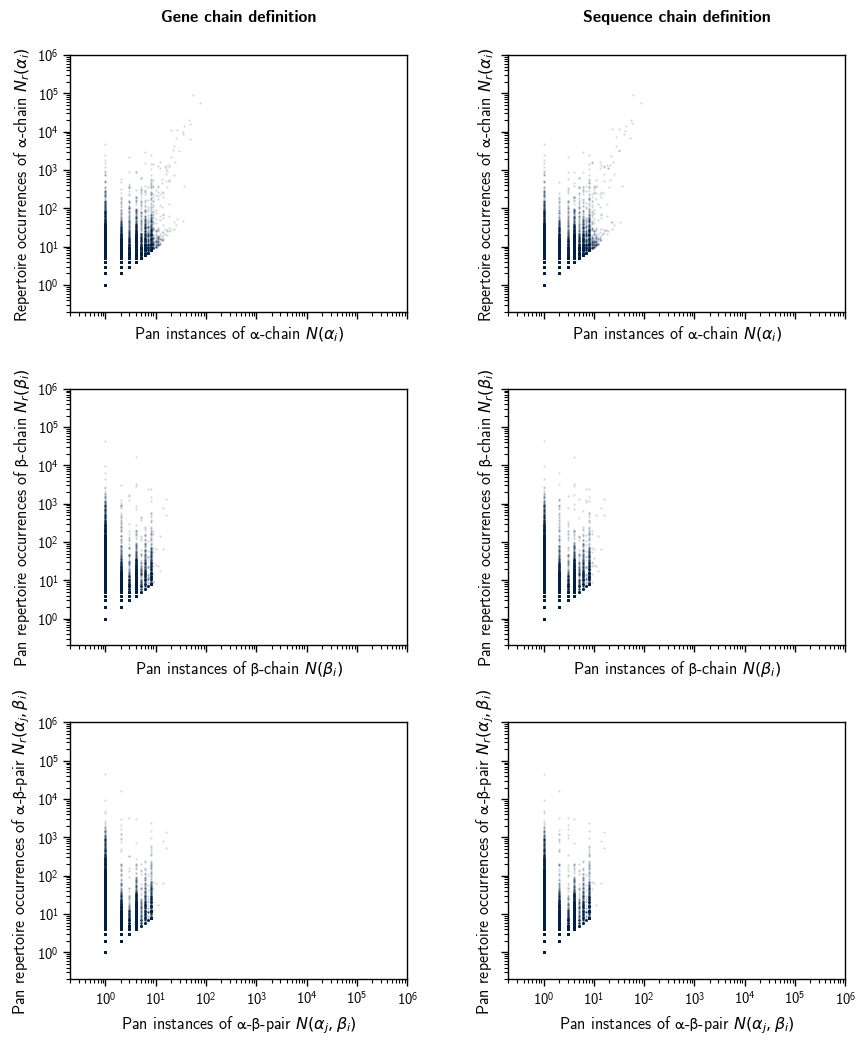

In [279]:
fig, axes = plt.subplots(3,2, figsize=(10,12), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

axes[0,0].scatter(gene_alphas.PanRepertoires, gene_alphas.PanInstances, s=1, alpha=0.1)
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')
axes[0,0].set_xlabel(r"Pan instances of α-chain $N(\alpha_i)$")
axes[0,0].set_ylabel(r"Repertoire occurrences of α-chain $N_r(\alpha_i)$")
axes[0,0].set_title('Gene chain definition', y=1.1)
axes[0,0].set_xlim(0.2,1e6)
axes[0,0].set_ylim(0.2,1e6)

axes[0,1].scatter(aa_alphas.PanRepertoires, aa_alphas.PanInstances, s=1, alpha=0.1)
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')
axes[0,1].set_xlabel(r"Pan instances of α-chain $N(\alpha_i)$")
axes[0,1].set_ylabel(r"Repertoire occurrences of α-chain $N_r(\alpha_i)$")
axes[0,1].set_title('Sequence chain definition', y=1.1)
axes[0,1].set_xlim(0.2,1e6)
axes[0,1].set_ylim(0.2,1e6)

axes[1,0].scatter(gene_betas.PanRepertoires, gene_betas.PanInstances, s=1, alpha=0.1)
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")
axes[1,0].set_ylabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")
axes[1,0].set_xlim(0.2,1e6)
axes[1,0].set_ylim(0.2,1e6)

axes[1,1].scatter(aa_betas.PanRepertoires, aa_betas.PanInstances, s=1, alpha=0.1)
axes[1,1].set_xscale('log')
axes[1,1].set_yscale('log')
axes[1,1].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")
axes[1,1].set_ylabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")
axes[1,1].set_xlim(0.2,1e6)
axes[1,1].set_ylim(0.2,1e6)

axes[2,0].scatter(gene_pairs.PanRepertoires, gene_pairs.PanInstances, s=1, alpha=0.1)
axes[2,0].set_xscale('log')
axes[2,0].set_yscale('log')
axes[2,0].set_xlabel(r"Pan instances of α-β-pair $N(\alpha_j,\beta_i)$")
axes[2,0].set_ylabel(r"Pan repertoire occurrences of α-β-pair $N_r(\alpha_j,\beta_i)$")
axes[2,0].set_xlim(0.2,1e6)
axes[2,0].set_ylim(0.2,1e6)

axes[2,1].scatter(aa_pairs.PanRepertoires, aa_pairs.PanInstances, s=1, alpha=0.1)
axes[2,1].set_xscale('log')
axes[2,1].set_yscale('log')
axes[2,1].set_xlabel(r"Pan instances of α-β-pair $N(\alpha_j,\beta_i)$")
axes[2,1].set_ylabel(r"Pan repertoire occurrences of α-β-pair $N_r(\alpha_j,\beta_i)$")
axes[2,1].set_xlim(0.2,1e6)
axes[2,1].set_ylim(0.2,1e6)

plt.savefig("figures/instances_correlation.png", dpi=600, bbox_inches='tight', transparent=True)

## 3 Public TCRs

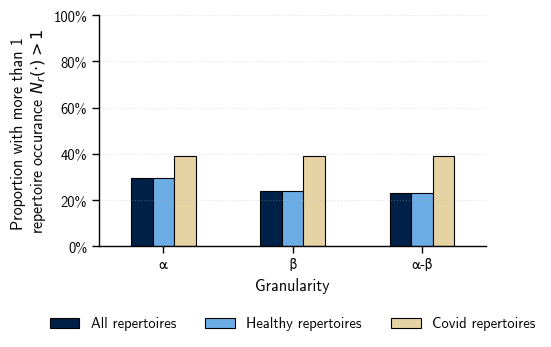

In [280]:
fig, ax = plt.subplots(figsize=(5,3))

pd.DataFrame({
    'All repertoires': {
        'α': (aa_alphas.PanRepertoires > 1).mean(),
        'β': (aa_betas.PanRepertoires > 1).mean(),
        'α-β': (aa_pairs.PanRepertoires > 1).mean(),
    },
    'Healthy repertoires': {
        'α': (aa_alphas_healthy.PanRepertoires > 1).mean(),
        'β': (aa_betas_healthy.PanRepertoires > 1).mean(),
        'α-β': (aa_pairs_healthy.PanRepertoires > 1).mean(),
    },
    'Covid repertoires': {
        'α': (aa_alphas_covid.PanRepertoires > 1).mean(),
        'β': (aa_alphas_covid.PanRepertoires > 1).mean(),
        'α-β': (aa_alphas_covid.PanRepertoires > 1).mean(),
    },
}).plot(
    kind='bar', ax=ax,
    color=[vis.blue, vis.light_blue, vis.light_gold], edgecolor='k',
)

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
if ax.get_legend():
    old_legend = ax.get_legend()
    handles = old_legend.legend_handles
    labels = [t.get_text() for t in old_legend.get_texts()]
    old_legend.remove()
ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -.25),
    ncol=3,
    frameon=False,
    title=None,
)
ax.set_ylim(0,1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
vis.percent_axis('y')
ax.grid(axis='y', linestyle='dotted', alpha=0.35)

ax.set_xlabel("Granularity")
ax.set_ylabel("Proportion with more than 1 \n"+r"repertoire occurance $N_r(\cdot) > 1$")

plt.savefig("figures/public_rate.png", dpi=600, bbox_inches='tight', transparent=True)

## 4 Diversity by uniqueness

In [281]:
# Defining instance bins
instance_bin_edges = np.array([0, 50, 100, 500, 1000, 5000, 100000])
instance_bin_labels = '(' + instance_bin_edges[:-1].astype(str) + ':' + instance_bin_edges[1:].astype(str) + ']'
instance_bin_labels[0] = '[1:' + instance_bin_edges[1].astype(str) + ']'
instance_bin_labels[-1] = str(instance_bin_edges[-2]) + '+'

In [282]:
# Defining repertoire bins
repertoire_bin_edges = np.array([0, 50, 100, 150, 200, 250, 300])
repertoire_bin_labels = '(' + repertoire_bin_edges[:-1].astype(str) + ':' + repertoire_bin_edges[1:].astype(str) + ']'
repertoire_bin_labels[0] = '[1:' + repertoire_bin_edges[1].astype(str) + ']'
repertoire_bin_labels[-1] = str(repertoire_bin_edges[-2]) + '+'

### 4.1 Pan-repertoire

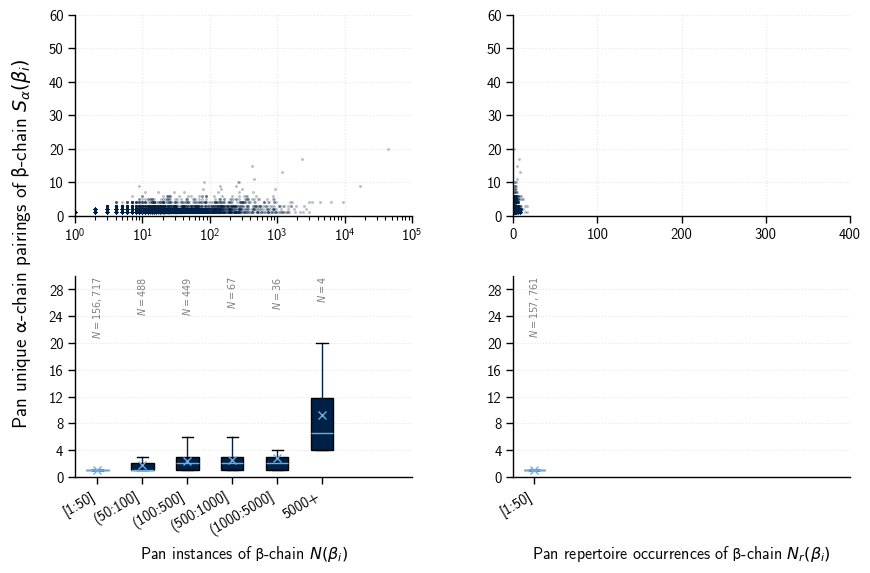

In [283]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.blue),
    whiskerprops=dict(color=vis.blue), medianprops=dict(color=vis.light_blue),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_blue)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas.PanInstances,
    gene_betas.PanUniquePairings,
    s=2,
    alpha=0.2
)
axes[0,0].scatter(
    gene_betas[gene_betas.PanUniquePairings > 60].PanInstances,
    [59]*round((gene_betas.PanUniquePairings > 60).sum()),
    s=15, marker='^', color=vis.blue,
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,60)
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas.groupby(pd.cut(gene_betas.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).PanUniquePairings.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,30)
axes[1,0].set_yticks(range(0,31,4))
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 30, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")

# Scatterplot by PanRepertoires
axes[0,1].scatter(
    gene_betas.PanRepertoires,
    gene_betas.PanUniquePairings,
    s=2,
    alpha=0.2
)
axes[0,1].scatter(
    gene_betas[gene_betas.PanUniquePairings > 60].PanRepertoires,
    [59]*round((gene_betas.PanUniquePairings > 60).sum()),
    s=15, marker='^', color=vis.blue,
)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)
axes[0,1].set_xlim(0,400)
axes[0,1].set_ylim(0,60)
axes[0,1].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanRepertoires
gene_betas_bins = gene_betas.groupby(pd.cut(gene_betas.PanRepertoires, bins=repertoire_bin_edges, labels=repertoire_bin_labels)).PanUniquePairings.apply(list)
axes[1,1].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,1].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,1].set_xlim(0.5,8.5)
axes[1,1].set_ylim(0,30)
axes[1,1].set_yticks(range(0,31,4))
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)
axes[1,1].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,1].text(i+1, 30, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")

# Common elements
fig.supylabel(r"Pan unique α-chain pairings of β-chain $S_\alpha(\beta_i)$", x=0.06)
fig.align_xlabels()

plt.savefig("figures/diversity_uniqueness_pan.png", dpi=600, bbox_inches='tight', transparent=True)

### 4.2 Intra-repertoire

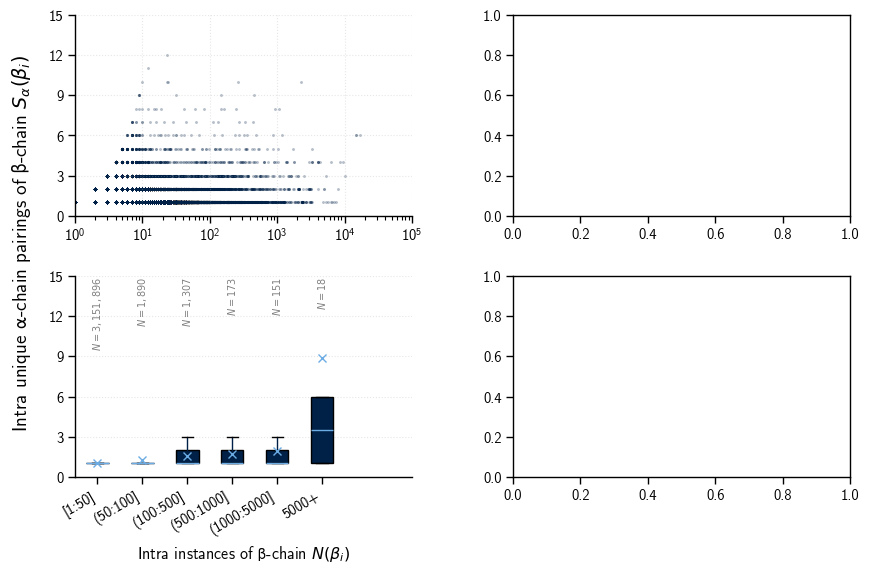

In [284]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.blue),
    whiskerprops=dict(color=vis.blue), medianprops=dict(color=vis.light_blue),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_blue)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas_intra.PanInstances,
    gene_betas_intra.PanUniquePairings,
    s=2,
    alpha=0.2
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,15)
axes[0,0].set_yticks(range(0,16,3))
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas_intra.groupby(pd.cut(gene_betas_intra.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).PanUniquePairings.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,15)
axes[1,0].set_yticks(range(0,16,3))
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 15, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Intra instances of β-chain $N(\beta_i)$")

# Common elements
fig.supylabel(r"Intra unique α-chain pairings of β-chain $S_\alpha(\beta_i)$", x=0.06)

plt.savefig("figures/diversity_uniqueness_intra.png", dpi=600, bbox_inches='tight', transparent=True)

In [285]:
# Unique beta pairings comparison of pan- and intra-repertoire
pd.DataFrame({
    "Pan-repertoire":[
        (gene_alphas.PanUniquePairings == 1).sum(),
        (gene_alphas.PanUniquePairings == 2).sum(),
        (gene_alphas.PanUniquePairings == 3).sum(),
        (gene_alphas.PanUniquePairings == 4).sum(),
        (gene_alphas.PanUniquePairings >= 5).sum(),
        len(gene_alphas)
    ],
    "Intra-repertoire": [
        (gene_alphas.explode("IntraUniquePairings").IntraUniquePairings == 1).sum(),
        (gene_alphas.explode("IntraUniquePairings").IntraUniquePairings == 2).sum(),
        (gene_alphas.explode("IntraUniquePairings").IntraUniquePairings == 3).sum(),
        (gene_alphas.explode("IntraUniquePairings").IntraUniquePairings == 4).sum(),
        (gene_alphas.explode("IntraUniquePairings").IntraUniquePairings >= 5).sum(),
        len(gene_alphas.explode("IntraUniquePairings"))
    ]
}, index=pd.Series(["1", "2", "3", "4", "5+", "Total"], name="Unique pairings")).map(lambda c: f"{c:,}")

,Pan-repertoire,Intra-repertoire
Unique pairings,,
1,"124,009","196,357"
2,"8,567","3,294"
3,"1,907",481
4,592,173
5+,672,434
Total,"135,747","200,739"


In [286]:
# Unique alpha pairings comparison of pan- and intra-repertoire
pd.DataFrame({
    "Pan-repertoire":[
        (gene_betas.PanUniquePairings == 1).sum(),
        (gene_betas.PanUniquePairings == 2).sum(),
        (gene_betas.PanUniquePairings == 3).sum(),
        (gene_betas.PanUniquePairings == 4).sum(),
        (gene_betas.PanUniquePairings >= 5).sum(),
        len(gene_betas)
    ],
    "Intra-repertoire": [
        (gene_betas.explode("IntraUniquePairings").IntraUniquePairings == 1).sum(),
        (gene_betas.explode("IntraUniquePairings").IntraUniquePairings == 2).sum(),
        (gene_betas.explode("IntraUniquePairings").IntraUniquePairings == 3).sum(),
        (gene_betas.explode("IntraUniquePairings").IntraUniquePairings == 4).sum(),
        (gene_betas.explode("IntraUniquePairings").IntraUniquePairings >= 5).sum(),
        len(gene_betas.explode("IntraUniquePairings"))
    ]
}, index=pd.Series(["1", "2", "3", "4", "5+", "Total"], name="Unique pairings")).map(lambda c: f"{c:,}")

,Pan-repertoire,Intra-repertoire
Unique pairings,,
1,"153,415","207,248"
2,"3,509","3,211"
3,560,558
4,170,137
5+,107,78
Total,"157,761","211,232"


## 5 Diversity by perplexity

### 5.1 Pan-repertoire

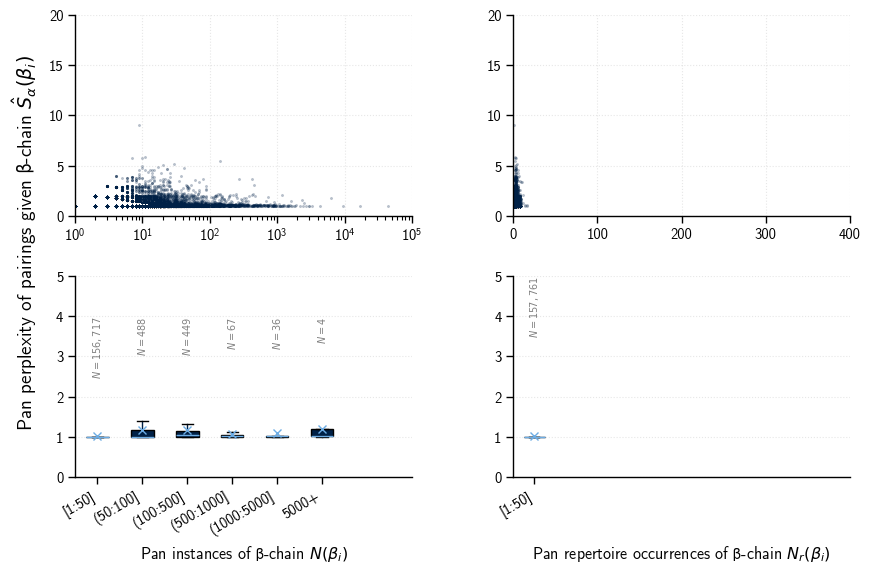

In [287]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.blue),
    whiskerprops=dict(color=vis.blue), medianprops=dict(color=vis.light_blue),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_blue)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas.PanInstances,
    gene_betas.Perplexity,
    s=2,
    alpha=0.2
)
axes[0,0].scatter(
    gene_betas[gene_betas.Perplexity > 20].PanInstances,
    [19.5]*round((gene_betas.Perplexity > 20).sum()),
    s=15, marker='^', color=vis.blue,
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,20)
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas.groupby(pd.cut(gene_betas.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).Perplexity.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,5)
axes[1,0].set_yticks(range(0,6,1))
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 4, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")

# Scatterplot by PanRepertoires
axes[0,1].scatter(
    gene_betas.PanRepertoires,
    gene_betas.Perplexity,
    s=2,
    alpha=0.2
)
axes[0,1].scatter(
    gene_betas[gene_betas.Perplexity > 20].PanRepertoires,
    [19.5]*round((gene_betas.Perplexity > 20).sum()),
    s=15, marker='^', color=vis.blue,
)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)
axes[0,1].set_xlim(0,400)
axes[0,1].set_ylim(0,20)
axes[0,1].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanRepertoires
gene_betas_bins = gene_betas.groupby(pd.cut(gene_betas.PanRepertoires, bins=repertoire_bin_edges, labels=repertoire_bin_labels)).Perplexity.apply(list)
axes[1,1].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,1].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,1].set_xlim(0.5,8.5)
axes[1,1].set_ylim(0,4)
axes[1,1].set_yticks(range(0,6,1))
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)
axes[1,1].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,1].text(i+1, 5, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")

# Common elements
fig.supylabel(r"Pan perplexity of pairings given β-chain $\hat{S}_\alpha(\beta_i)$", x=0.06)
fig.align_xlabels()

plt.savefig("figures/diversity_perplexity_pan.png", dpi=600, bbox_inches='tight', transparent=True)

### 5.2 Intra-repertoire

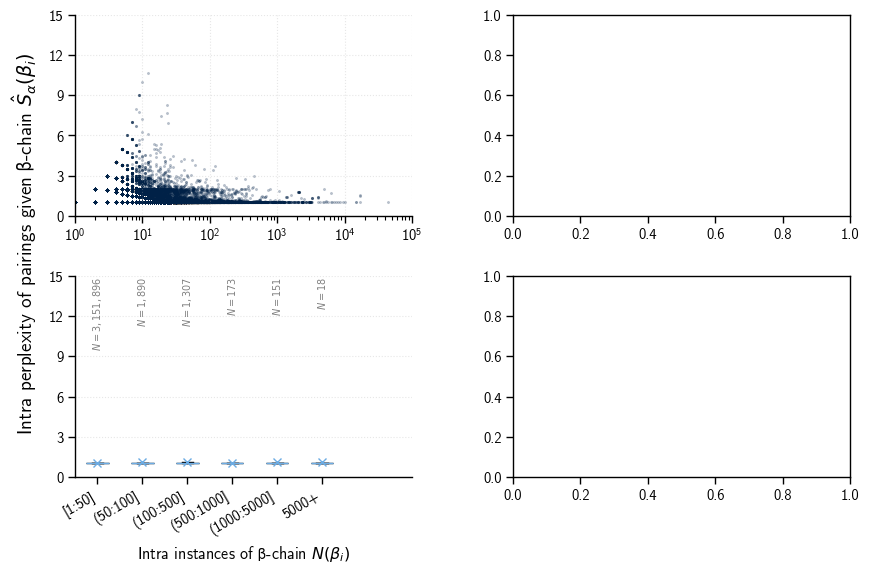

In [288]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.blue),
    whiskerprops=dict(color=vis.blue), medianprops=dict(color=vis.light_blue),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_blue)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas_intra.PanInstances,
    gene_betas_intra.Perplexity,
    s=2,
    alpha=0.2
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,15)
axes[0,0].set_yticks(range(0,16,3))
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas_intra.groupby(pd.cut(gene_betas_intra.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).Perplexity.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,15)
axes[1,0].set_yticks(range(0,16,3))
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 15, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Intra instances of β-chain $N(\beta_i)$")

# Common elements
fig.supylabel(r"Intra perplexity of pairings given β-chain $\hat{S}_\alpha(\beta_i)$", x=0.06)

plt.savefig("figures/diversity_perplexity_intra.png", dpi=600, bbox_inches='tight', transparent=True)

## 6 Diversity by Simpson index

### 6.1 Pan-repertoire

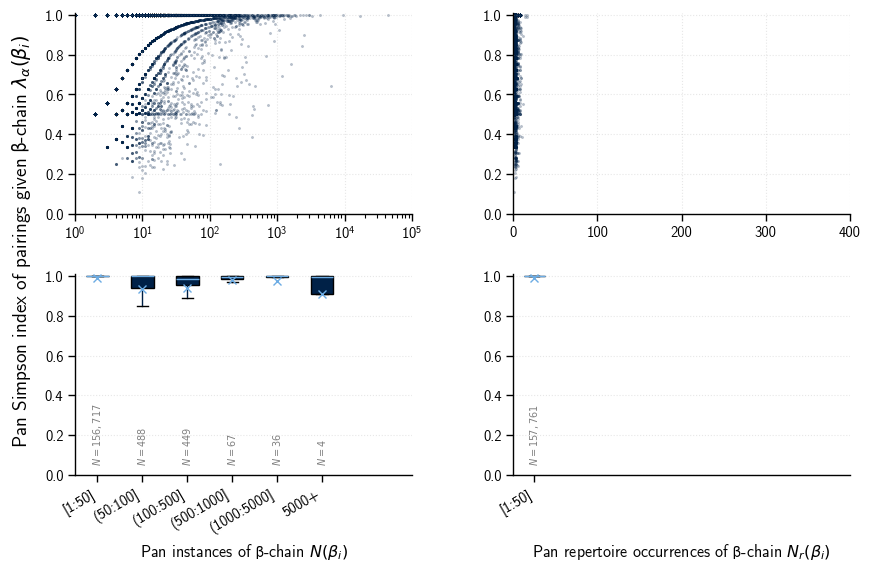

In [289]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.blue),
    whiskerprops=dict(color=vis.blue), medianprops=dict(color=vis.light_blue),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_blue)
)
text_kwargs = dict(
    ha='center', va='bottom',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas.PanInstances,
    gene_betas.SimpsonIndex,
    s=2, c=vis.blue, alpha=0.2
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,1.01)
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas.groupby(pd.cut(gene_betas.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).SimpsonIndex.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,1.01)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 0.05, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")

# Scatterplot by PanRepertoires
axes[0,1].scatter(
    gene_betas.PanRepertoires,
    gene_betas.SimpsonIndex,
    s=2, c=vis.blue, alpha=0.2
)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)
axes[0,1].set_xlim(0,400)
axes[0,1].set_ylim(0,1.01)
axes[0,1].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanRepertoires
gene_betas_bins = gene_betas.groupby(pd.cut(gene_betas.PanRepertoires, bins=repertoire_bin_edges, labels=repertoire_bin_labels)).SimpsonIndex.apply(list)
axes[1,1].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,1].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,1].set_xlim(0.5,8.5)
axes[1,1].set_ylim(0,1.01)
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)
axes[1,1].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,1].text(i+1, 0.05, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")

# Common elements
fig.supylabel(r"Pan Simpson index of pairings given β-chain $\lambda_\alpha(\beta_i)$", x=0.06)
fig.align_xlabels()

plt.savefig("figures/diversity_simpson_pan.png", dpi=600, bbox_inches='tight', transparent=True)

In [290]:
# Repertoire-occurrence-weighted confusion rate
(
    gene_betas
    .groupby(
        pd.cut(
            gene_betas.PanInstances,
            bins=instance_bin_edges,
            labels=instance_bin_labels
        ))
    .apply(lambda subset: ((1 - subset.SimpsonIndex) * subset.PanRepertoires).sum() / subset.PanRepertoires.sum())
)

s = gene_betas[gene_betas.PanRepertoires > 100]
((1 - s.SimpsonIndex) * s.PanRepertoires).sum() / s.PanRepertoires.sum()

/var/folders/ls/l5m3kcsd4lddcv2284nfc4b40000gn/T/ipykernel_1146/676356736.py:14: RuntimeWarning: invalid value encountered in scalar divide
  ((1 - s.SimpsonIndex) * s.PanRepertoires).sum() / s.PanRepertoires.sum()


np.float64(nan)

/Users/frederikespersenknudsen/Repositories/tcr-ab-pairing-diversity/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) CMU Sans Serif.
  self._figure.tight_layout(*args, **kwargs)


(0.0, 1.0)

/Users/frederikespersenknudsen/Repositories/tcr-ab-pairing-diversity/.venv/lib/python3.13/site-packages/IPython/core/events.py:96: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) CMU Sans Serif.
  func(*args, **kwargs)
/Users/frederikespersenknudsen/Repositories/tcr-ab-pairing-diversity/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) CMU Sans Serif.
  fig.canvas.print_figure(bytes_io, **kw)


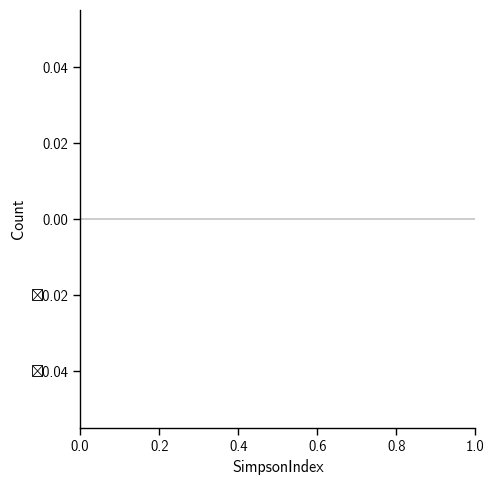

In [291]:
sns.displot(
    aa_betas[aa_betas.PanRepertoires > 100],
    x='SimpsonIndex',
    bins=100
)
plt.xlim(0,1)

### 6.2 Intra-repertoire

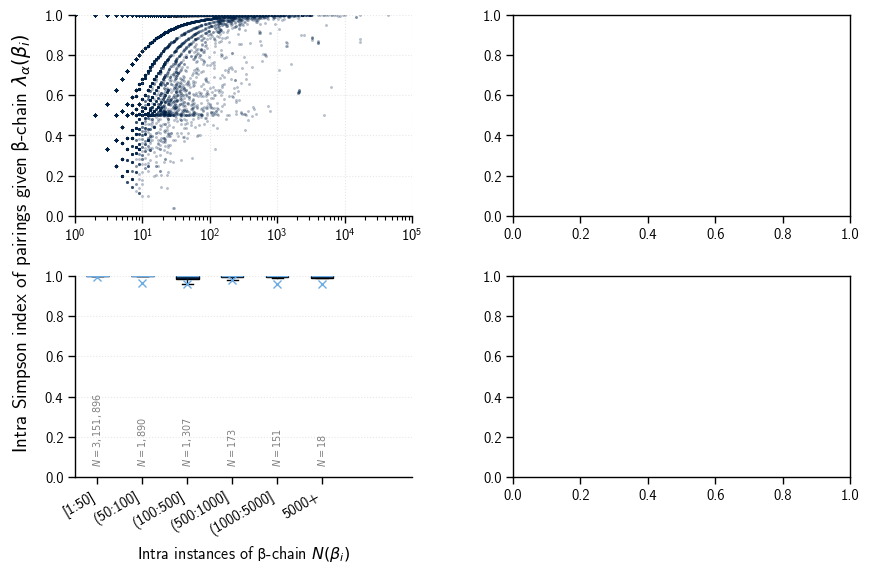

In [292]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.blue),
    whiskerprops=dict(color=vis.blue), medianprops=dict(color=vis.light_blue),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_blue)
)
text_kwargs = dict(
    ha='center', va='bottom',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas_intra.PanInstances,
    gene_betas_intra.SimpsonIndex,
    s=2,
    alpha=0.2
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,1)
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas_intra.groupby(pd.cut(gene_betas_intra.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).SimpsonIndex.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,1)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 0.05, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Intra instances of β-chain $N(\beta_i)$")

# Common elements
fig.supylabel(r"Intra Simpson index of pairings given β-chain $\lambda_\alpha(\beta_i)$", x=0.06)

plt.savefig("figures/diversity_simpson_intra.png", dpi=600, bbox_inches='tight', transparent=True)

## 7 Diversity by expected edit distance

### 7.1 CDR3

#### 7.1.1 Pan-repertoire

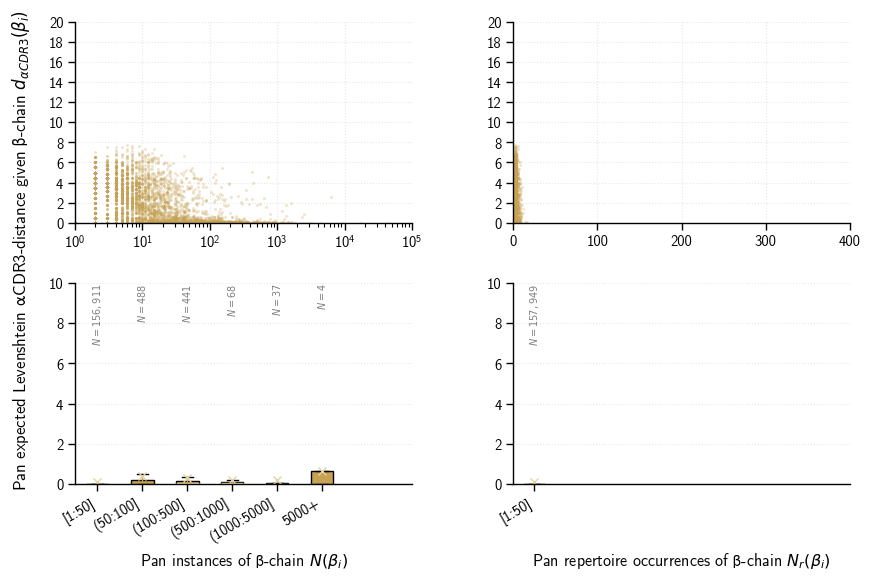

In [293]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.gold),
    whiskerprops=dict(color=vis.gold), medianprops=dict(color=vis.light_gold),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_gold)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    aa_betas.PanInstances,
    aa_betas.ExpectedCDR3Levenshtein,
    s=2, c=vis.gold, alpha=0.2
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,20)
axes[0,0].set_yticks(range(0,21,2))
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
aa_betas_bins = aa_betas.groupby(pd.cut(aa_betas.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).ExpectedCDR3Levenshtein.apply(list)
axes[1,0].boxplot(
    aa_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(aa_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,10)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(aa_betas_bins):
    axes[1,0].text(i+1, 10, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")

# Scatterplot by PanRepertoires
axes[0,1].scatter(
    aa_betas.PanRepertoires,
    aa_betas.ExpectedCDR3Levenshtein,
    s=2, c=vis.gold, alpha=0.2
)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)
axes[0,1].set_xlim(0,400)
axes[0,1].set_ylim(0,20)
axes[0,1].set_yticks(range(0,21,2))
axes[0,1].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanRepertoires
aa_betas_bins = aa_betas.groupby(pd.cut(aa_betas.PanRepertoires, bins=repertoire_bin_edges, labels=repertoire_bin_labels)).ExpectedCDR3Levenshtein.apply(list)
axes[1,1].boxplot(
    aa_betas_bins,
    **boxplot_kwargs
)
axes[1,1].set_xticklabels(aa_betas_bins.index, rotation=30, ha='right')
axes[1,1].set_xlim(0.5,8.5)
axes[1,1].set_ylim(0,10)
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)
axes[1,1].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(aa_betas_bins):
    axes[1,1].text(i+1, 10, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")

# Common elements
fig.supylabel(r"Pan expected Levenshtein αCDR3-distance given β-chain $d_{{\alpha}CDR3}(\beta_i)$", x=0.06, fontsize=12)
fig.align_xlabels()

plt.savefig("figures/diversity_levenshtein_cdr3_pan.png", dpi=600, bbox_inches='tight', transparent=True)

#### 7.1.2 Intra-repertoire

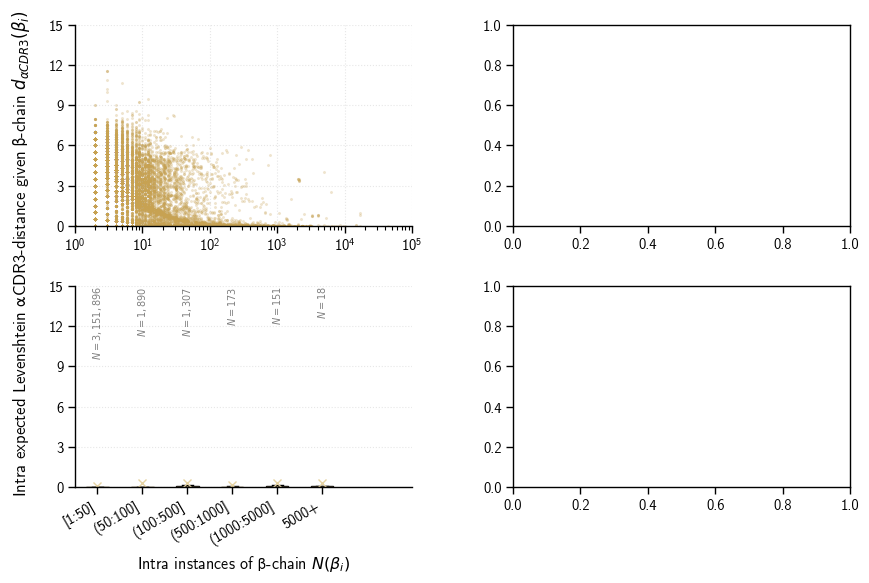

In [294]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.gold),
    whiskerprops=dict(color=vis.gold), medianprops=dict(color=vis.light_gold),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_gold)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    gene_betas_intra.PanInstances,
    gene_betas_intra.ExpectedCDR3Levenshtein,
    s=2, alpha=0.2, c=vis.gold
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,15)
axes[0,0].set_yticks(range(0,16,3))
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = gene_betas_intra.groupby(pd.cut(gene_betas_intra.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).ExpectedCDR3Levenshtein.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,15)
axes[1,0].set_yticks(range(0,16,3))
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 15, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Intra instances of β-chain $N(\beta_i)$")

# Common elements
fig.supylabel(r"Intra expected Levenshtein αCDR3-distance given β-chain $d_{{\alpha}CDR3}(\beta_i)$", x=0.06, fontsize=12)

plt.savefig("figures/diversity_levenshtein_cdr3_intra.png", dpi=600, bbox_inches='tight', transparent=True)

### 7.2 All CDRs

In [295]:
def chain_agg_cdrs_levdist(pair_instances, cdr1_aa_seqs, cdr2_aa_seqs, cdr3_aa_seqs):
    # Precalculating tensors
    pair_instances = np.array(pair_instances)
    p_a_b = pair_instances / pair_instances.sum()
    p_aa_b = np.outer(p_a_b, p_a_b)

    # Expected Levenshtein
    d_aa_1 = distance_matrix(cdr1_aa_seqs, levdist)
    exp_dist_lev_cdr1 = (p_aa_b * d_aa_1).sum()
    d_aa_2 = distance_matrix(cdr2_aa_seqs, levdist)
    exp_dist_lev_cdr2 = (p_aa_b * d_aa_2).sum()
    d_aa_3 = distance_matrix(cdr3_aa_seqs, levdist)
    exp_dist_lev_cdr3 = (p_aa_b * d_aa_3).sum()
    exp_dist_lev_cdrs = exp_dist_lev_cdr1 + exp_dist_lev_cdr2 + exp_dist_lev_cdr3

    return pd.Series({
        'ExpectedCDR1Levenshtein': exp_dist_lev_cdr1,
        'ExpectedCDR2Levenshtein': exp_dist_lev_cdr2,
        'ExpectedCDR3Levenshtein': exp_dist_lev_cdr3,
        'ExpectedCDRsLevenshtein': exp_dist_lev_cdrs,
    })

#### 7.2.1 Pan-repertoire

In [296]:
try:
    aa_betas_cdrs_levdist = pd.read_parquet('data/ots/curated/aa_betas_cdrs_levdist.parquet')

except FileNotFoundError:
    aa_betas_cdrs_levdist = aa_pairs.groupby(aa_beta_features).apply(lambda subset:
        chain_agg_cdrs_levdist(
            subset.PanInstances,
            subset.index.get_level_values('cdr1_aa_alpha'),
            subset.index.get_level_values('cdr2_aa_alpha'),
            subset.index.get_level_values('cdr3_aa_alpha'),
        )
    )

    aa_betas_cdrs_levdist.to_parquet('data/ots/curated/aa_betas_cdrs_levdist.parquet')

assert (aa_betas.index == aa_betas_cdrs_levdist.index).all()
if not aa_betas_cdrs_levdist.columns.isin(aa_betas.columns).all():
    aa_betas = aa_betas.drop('ExpectedCDR3Levenshtein', axis=1).merge(aa_betas_cdrs_levdist, left_index=True, right_index=True)

ValueError: Lengths must match to compare

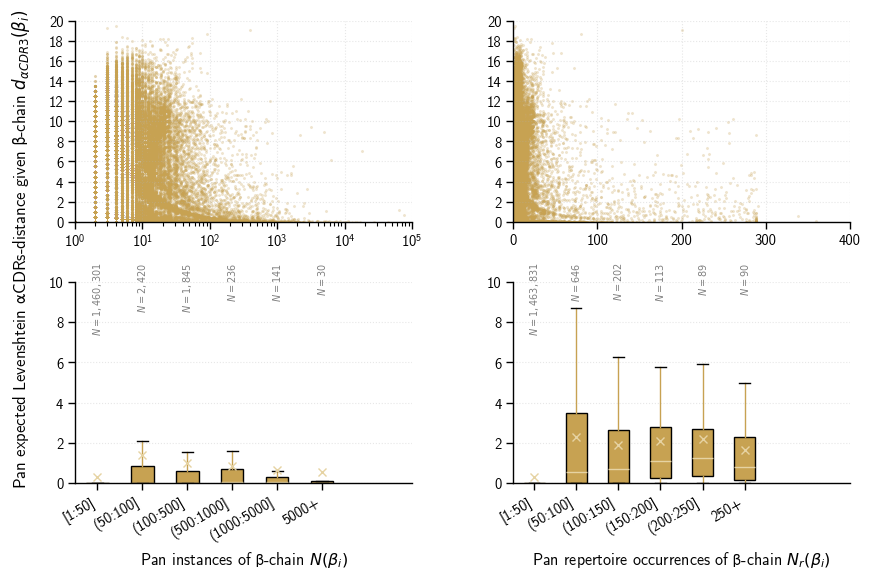

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.gold),
    whiskerprops=dict(color=vis.gold), medianprops=dict(color=vis.light_gold),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_gold)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    aa_betas.PanInstances,
    aa_betas.ExpectedCDRsLevenshtein,
    s=2, c=vis.gold, alpha=0.2
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,20)
axes[0,0].set_yticks(range(0,21,2))
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
aa_betas_bins = aa_betas.groupby(pd.cut(aa_betas.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).ExpectedCDRsLevenshtein.apply(list)
axes[1,0].boxplot(
    aa_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(aa_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,10)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(aa_betas_bins):
    axes[1,0].text(i+1, 11, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Pan instances of β-chain $N(\beta_i)$")

# Scatterplot by PanRepertoires
axes[0,1].scatter(
    aa_betas.PanRepertoires,
    aa_betas.ExpectedCDRsLevenshtein,
    s=2, c=vis.gold, alpha=0.2
)
axes[0,1].spines.right.set_visible(False)
axes[0,1].spines.top.set_visible(False)
axes[0,1].set_xlim(0,400)
axes[0,1].set_ylim(0,20)
axes[0,1].set_yticks(range(0,21,2))
axes[0,1].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanRepertoires
aa_betas_bins = aa_betas.groupby(pd.cut(aa_betas.PanRepertoires, bins=repertoire_bin_edges, labels=repertoire_bin_labels)).ExpectedCDRsLevenshtein.apply(list)
axes[1,1].boxplot(
    aa_betas_bins,
    **boxplot_kwargs
)
axes[1,1].set_xticklabels(aa_betas_bins.index, rotation=30, ha='right')
axes[1,1].set_xlim(0.5,8.5)
axes[1,1].set_ylim(0,10)
axes[1,1].spines.right.set_visible(False)
axes[1,1].spines.top.set_visible(False)
axes[1,1].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(aa_betas_bins):
    axes[1,1].text(i+1, 11, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,1].set_xlabel(r"Pan repertoire occurrences of β-chain $N_r(\beta_i)$")

# Common elements
fig.supylabel(r"Pan expected Levenshtein αCDRs-distance given β-chain $d_{{\alpha}CDR3}(\beta_i)$", x=0.06, fontsize=12)
fig.align_xlabels()

plt.savefig("figures/diversity_levenshtein_cdrs_pan.png", dpi=600, bbox_inches='tight', transparent=True)

#### 7.2.2 Intra-repertoire

In [ ]:
try:
    aa_betas_intra_cdrs_levdist = pd.read_parquet('data/ots/curated/aa_betas_cdrs_levdist_intra.parquet')

except FileNotFoundError:
    aa_betas_intra_cdrs_levdist = aa_pairs_intra.groupby(['RepertoireId'] + aa_beta_features).apply(lambda subset:
        chain_agg_cdrs_levdist(
            subset.PanInstances,
            subset.index.get_level_values('cdr1_aa_alpha'),
            subset.index.get_level_values('cdr2_aa_alpha'),
            subset.index.get_level_values('cdr3_aa_alpha'),
        )
    )

    aa_betas_intra_cdrs_levdist.to_parquet('data/ots/curated/aa_betas_cdrs_levdist_intra.parquet')

assert (aa_betas_intra.index == aa_betas_intra_cdrs_levdist.index).all()
if not aa_betas_intra_cdrs_levdist.columns.isin(aa_betas_intra.columns).all():
    aa_betas_intra = aa_betas_intra.drop('ExpectedCDR3Levenshtein', axis=1).merge(aa_betas_intra_cdrs_levdist, left_index=True, right_index=True)

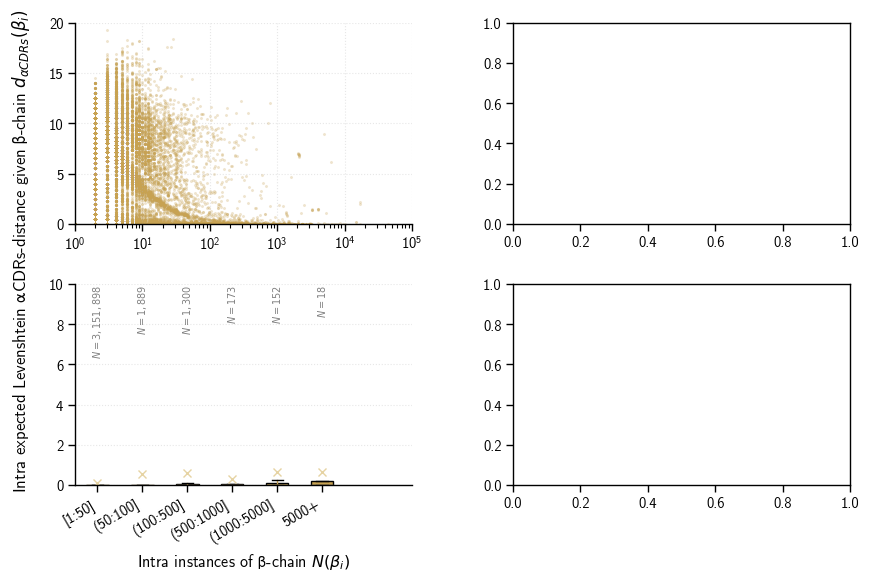

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

boxplot_kwargs = dict(
    widths=0.5,
    patch_artist=True, boxprops=dict(color='k', facecolor=vis.gold),
    whiskerprops=dict(color=vis.gold), medianprops=dict(color=vis.light_gold),
    showfliers=False, showmeans=True, meanprops=dict(marker='x', markeredgecolor=vis.light_gold)
)
text_kwargs = dict(
    ha='center', va='top',
    fontsize=7, color='k', rotation=90,
    alpha=.5
)

# Scatterplot by PanInstances
axes[0,0].scatter(
    aa_betas_intra.PanInstances,
    aa_betas_intra.ExpectedCDRsLevenshtein,
    s=2, alpha=0.2, c=vis.gold
)
axes[0,0].spines.right.set_visible(False)
axes[0,0].spines.top.set_visible(False)
axes[0,0].set_xlim(1,1e5)
axes[0,0].set_ylim(0,20)
axes[0,0].set_xscale('log')
axes[0,0].grid(linestyle='dotted', alpha=0.3)

# Boxplot by PanInstances
gene_betas_bins = aa_betas_intra.groupby(pd.cut(aa_betas_intra.PanInstances, bins=instance_bin_edges, labels=instance_bin_labels)).ExpectedCDRsLevenshtein.apply(list)
axes[1,0].boxplot(
    gene_betas_bins,
    **boxplot_kwargs
)
axes[1,0].set_xticklabels(gene_betas_bins.index, rotation=30, ha='right')
axes[1,0].set_xlim(0.5,8)
axes[1,0].set_ylim(0,10)
axes[1,0].spines.right.set_visible(False)
axes[1,0].spines.top.set_visible(False)
axes[1,0].grid(axis='y', linestyle='dotted', alpha=0.3)
for i, bin_list in enumerate(gene_betas_bins):
    axes[1,0].text(i+1, 10, f"$N={len(bin_list):,}$", **text_kwargs)
axes[1,0].set_xlabel(r"Intra instances of β-chain $N(\beta_i)$")

# Common elements
fig.supylabel(r"Intra expected Levenshtein αCDRs-distance given β-chain $d_{{\alpha}CDRs}(\beta_i)$", x=0.06, fontsize=12)

plt.savefig("figures/diversity_levenshtein_cdrs_intra.png", dpi=600, bbox_inches='tight', transparent=True)

## 8 Non-singleton subset

## 9 Diversity regimes

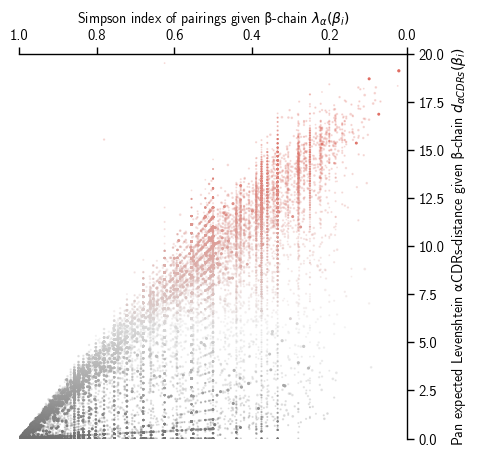

In [ ]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1,1, figsize=(5,5))

aa_betas_ns = aa_betas[aa_betas.PanUniquePairings > 1]

# Radius from origo
r = np.linalg.norm(np.vstack([
    aa_betas_ns.SimpsonIndex,
    20-aa_betas_ns.ExpectedCDRsLevenshtein
]), axis=0)

ax.scatter(
    x=aa_betas_ns.SimpsonIndex,
    y=aa_betas_ns.ExpectedCDRsLevenshtein,
    s=aa_betas_ns.PanRepertoires.map(np.log10),
    alpha=aa_betas_ns.PanRepertoires.map(lambda r: 0.2 if r < 50 else 1),
    c=r**2, cmap=mcolors.LinearSegmentedColormap.from_list(
        "diversity_scale",
        [vis.coral, vis.light_gray, vis.gray]
    )
)

ax.set_xlim(1,0)
ax.set_ylim(0,20)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel(r"Simpson index of pairings given β-chain $\lambda_\alpha(\beta_i)$", fontsize=10)
ax.set_ylabel(r"Pan expected Levenshtein αCDRs-distance given β-chain $d_{{\alpha}CDRs}(\beta_i)$", fontsize=10)

fig.savefig("figures/diversity_regimes.png", dpi=600, bbox_inches='tight', transparent=True)

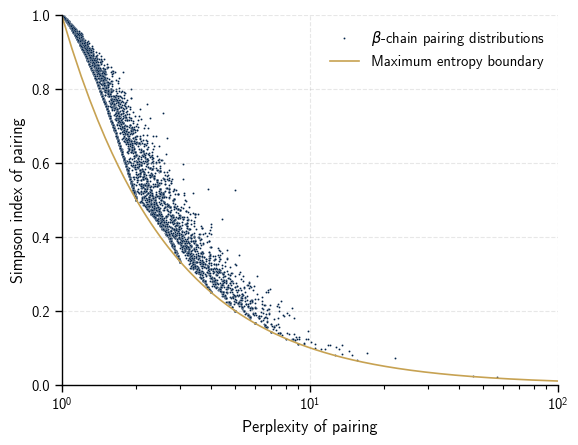

In [ ]:
sns.scatterplot(
    x=aa_betas_ns.Perplexity,
    y=aa_betas_ns.SimpsonIndex,
    s=2, label=r"$\beta$-chain pairing distributions"
)
y = np.linspace(1,100,1000)
plt.gca().spines[['right', 'top']].set_visible(False)
plt.plot(y, 1/y, color=vis.gold, label="Maximum entropy boundary")
plt.xlim(1,100)
plt.ylim(0,1)
plt.xscale('log')
plt.grid(alpha=0.3, linestyle='dashed')
plt.xlabel("Perplexity of pairing")
plt.ylabel("Simpson index of pairing")
plt.legend(frameon=False)

## 10 Example structure

In [ ]:
beta_example_aa = 'DAGVTQSPTHLIKTRGQQVTLRCSPKSGHDTVSWYQQALGQGPQFIFQYYEEEERQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLCASSFGQSSTYGYTFGSGTRLTVV'

In [ ]:
beta_seqs = aa_pairs.reset_index()[aa_beta_features].sum(axis=1)
examples = aa_pairs[(beta_seqs == beta_example_aa).values]
examples

PanInstances  \
fwr1_aa_alpha             cdr1_aa_alpha fwr2_aa_alpha     cdr2_aa_alpha fwr3_aa_alpha                      cdr3_aa_alpha fwr4_aa_alpha fwr1_aa_beta               cdr1_aa_beta fwr2_aa_beta      cdr2_aa_beta fwr3_aa_beta                          cdr3_aa_beta  fwr4_aa_beta                 
KDQVFQPSTVASSEGAVVEIFCNHS VSNAYN        FFWYLHFPGCAPRLLVK GSKP          SQQGRYNMTYERFSSSLLILQVREADAAVYYC   AVEDGRDDKII   FGKGTRLHILP   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV            4815   
LAKTTQPISMDSYEGQEVNITCSHN NIATNDY       ITWYQQFPSQGPRFIIQ GYKTK         VTNEVASLFIPADRKSSTLSLPRVSLSDTAVYYC LVGDMDQAGTALI FGKGTTLSVSS   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV              43   
                                                                                                           LVGDRDQAGTALI FGKGTTLSVSS   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV           13213   

                                                                                                                                                                                                                                                                                PanRepertoires  \
fwr1_aa_alpha             cdr1_aa_alpha fwr2_aa_alpha     cdr2_aa_alpha fwr3_aa_alpha                      cdr3_aa_alpha fwr4_aa_alpha fwr1_aa_beta               cdr1_aa_beta fwr2_aa_beta      cdr2_aa_beta fwr3_aa_beta                          cdr3_aa_beta  fwr4_aa_beta                   
KDQVFQPSTVASSEGAVVEIFCNHS VSNAYN        FFWYLHFPGCAPRLLVK GSKP          SQQGRYNMTYERFSSSLLILQVREADAAVYYC   AVEDGRDDKII   FGKGTRLHILP   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV                36   
LAKTTQPISMDSYEGQEVNITCSHN NIATNDY       ITWYQQFPSQGPRFIIQ GYKTK         VTNEVASLFIPADRKSSTLSLPRVSLSDTAVYYC LVGDMDQAGTALI FGKGTTLSVSS   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV                 5   
                                                                                                           LVGDRDQAGTALI FGKGTTLSVSS   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV                42   

                                                                                                                                                                                                                                                                                                                   IntraInstances  \
fwr1_aa_alpha             cdr1_aa_alpha fwr2_aa_alpha     cdr2_aa_alpha fwr3_aa_alpha                      cdr3_aa_alpha fwr4_aa_alpha fwr1_aa_beta               cdr1_aa_beta fwr2_aa_beta      cdr2_aa_beta fwr3_aa_beta                          cdr3_aa_beta  fwr4_aa_beta                                                      
KDQVFQPSTVASSEGAVVEIFCNHS VSNAYN        FFWYLHFPGCAPRLLVK GSKP          SQQGRYNMTYERFSSSLLILQVREADAAVYYC   AVEDGRDDKII   FGKGTRLHILP   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV    [49, 55, 56, 46, 4, 8, 11, 11, 7, 9, 8, 5, 4, ...   
LAKTTQPISMDSYEGQEVNITCSHN NIATNDY       ITWYQQFPSQGPRFIIQ GYKTK         VTNEVASLFIPADRKSSTLSLPRVSLSDTAVYYC LVGDMDQAGTALI FGKGTTLSVSS   DAGVTQSPTHLIKTRGQQVTLRCSPK SGHDT        VSWYQQALGQGPQFIFQ YYEEEE       RQRGNFPDRFSGHQFPNYSSELNVNALLLGDSALYLC ASSFGQSSTYGYT FGSGTRLTVV                                     [8, 10, 7, 9, 9]   
                                                                                

In [ ]:
reps = examples.RepertoireIds.map(set).values
reps = (reps[0]|reps[1]|reps[2])
dataunit_metadata[dataunit_metadata.RepertoireId.isin(reps)]

,Run,Link,Author,Disease,CancerType,Age,Longitudinal,Species,Strain,TSource,...,Subject,Sequences,SequencesPaired,SequencesPairedUnique,Path,Source,Isotype,Chain,SubjectProxy,RepertoireId
36,SRR10039384,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,2440,2315,32,data/ots/raw/SRR10039384_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039384,69
46,SRR10039377,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,1403,1397,7,data/ots/raw/SRR10039377_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039377,62
126,SRR10039376,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,1418,1409,9,data/ots/raw/SRR10039376_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039376,61
129,SRR10039385,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,2386,2266,32,data/ots/raw/SRR10039385_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039385,70
156,SRR10039386,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,2447,2317,32,data/ots/raw/SRR10039386_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039386,71
165,SRR10039375,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,3319,3310,25,data/ots/raw/SRR10039375_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039375,60
207,SRR10039374,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,3407,3397,14,data/ots/raw/SRR10039374_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039374,59
222,SRR10039387,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,2422,2295,32,data/ots/raw/SRR10039387_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039387,72
303,SRR10039372,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,3339,3330,12,data/ots/raw/SRR10039372_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039372,57
323,SRR10039398,https://pubmed.ncbi.nlm.nih.gov/31484655/,Luo et al. 2019,cancer,metastatic_epithelia,no,no,human,none,pbmc,...,no,1512,114,45,data/ots/raw/SRR10039398_1_Paired_All.csv.gz,NaN,NaN,NaN,SRR10039398,83
